In [1]:
import sys
from pathlib import Path
from types import SimpleNamespace
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from data.clean_data import basic_clean
from data.load_data import load_raw_data
from eda.summary import data_summary
from data.feature_engineering import prepare_model_data
from data.model_features import (
    get_grouped_model_feature_columns,
    split_feature_types,
)
from models.ridge_regression import (
    train_ridge_regression,
    predict_ridge_regression,
    get_transformed_predictions,
)

In [2]:
df_raw = load_raw_data()
df = basic_clean(df_raw)

target = "annual_medical_cost"
log_target = f"log1p_{target}"

df = prepare_model_data(
    df,
    target_col=target,
    add_log=True,
    add_groups=True,
    add_tail_flags=False,
)

print("Shape:", df.shape)
display(df.head())
display(data_summary(df))

Shape: (100000, 58)


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,log1p_annual_medical_cost,hospitalizations_grouped,chronic_count_grouped,days_hospitalized_grouped
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,2,0,1,0,0,8.844922,0,1,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,0,1,1,0,7.398548,0,2,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,2,1,0,1,0,8.944030,0,3,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,1,0,0,0,8.543108,0,1,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,1,0,1,0,7.439401,0,2,0


,dtype,missing_count,missing_pct,n_unique
alcohol_freq,str,30083,30.083,3
person_id,int64,0,0.000,100000
annual_medical_cost,float64,0,0.000,91299
log1p_annual_medical_cost,float64,0,0.000,91299
total_claims_paid,float64,0,0.000,56650
annual_premium,float64,0,0.000,55538
avg_claim_amount,float64,0,0.000,53071
monthly_premium,float64,0,0.000,12339
income,float64,0,0.000,2987
ldl,float64,0,0.000,1881


In [3]:
RANDOM_STATE = 42
TEST_SIZE = 0.20

BASE_ALPHA_GRID = np.logspace(-3, 3, 25)
WIDE_ALPHA_GRID = np.logspace(-5, 5, 61)

EXPERIMENT_CONFIGS = [
    {
        "name": "baseline_grouped",
        "feature_mode": "grouped",
        "alphas": BASE_ALPHA_GRID,
        "apply_smearing": False,
        "weighted": False,
    },
    {
        "name": "wider_alpha_grid",
        "feature_mode": "grouped",
        "alphas": WIDE_ALPHA_GRID,
        "apply_smearing": False,
        "weighted": False,
    },
    {
        "name": "raw_health_features",
        "feature_mode": "raw_health_features",
        "alphas": BASE_ALPHA_GRID,
        "apply_smearing": False,
        "weighted": False,
    },
    {
        "name": "grouped_without_days_hospitalized",
        "feature_mode": "grouped_without_days_hospitalized",
        "alphas": BASE_ALPHA_GRID,
        "apply_smearing": False,
        "weighted": False,
    },
    {
        "name": "grouped_with_interaction",
        "feature_mode": "grouped",
        "add_interaction": True,
        "alphas": BASE_ALPHA_GRID,
        "apply_smearing": False,
        "weighted": False,
    },
    {
        "name": "smearing_correction",
        "feature_mode": "grouped",
        "alphas": BASE_ALPHA_GRID,
        "apply_smearing": True,
        "weighted": False,
    },
    {
        "name": "weighted_ridge",
        "feature_mode": "grouped",
        "alphas": BASE_ALPHA_GRID,
        "apply_smearing": False,
        "weighted": True,
        "p95_weight": 5.0,
        "p99_weight": 10.0,
    },
]

In [4]:
def replace_feature(features, old_col, new_col, data):
    updated = [col for col in features if col != old_col]

    if new_col in data.columns and new_col not in updated:
        updated.append(new_col)

    return updated


def unique_preserve_order(values):
    seen = set()
    output = []

    for value in values:
        if value not in seen:
            output.append(value)
            seen.add(value)

    return output


def build_experiment_data_and_features(base_df, features_config, target_col):
    experiment_data = base_df.copy()

    feature_columns = get_grouped_model_feature_columns(
        experiment_data,
        target_col=target_col,
    )

    feature_mode = features_config.get("feature_mode", "grouped")

    if feature_mode == "raw_health_features":
        feature_columns = replace_feature(
            feature_columns,
            old_col="hospitalizations_grouped",
            new_col="hospitalizations_last_3yrs",
            data=experiment_data,
        )
        feature_columns = replace_feature(
            feature_columns,
            old_col="chronic_count_grouped",
            new_col="chronic_count",
            data=experiment_data,
        )
        feature_columns = replace_feature(
            feature_columns,
            old_col="days_hospitalized_grouped",
            new_col="days_hospitalized_last_3yrs",
            data=experiment_data,
        )

    elif feature_mode == "grouped_without_days_hospitalized":
        feature_columns = [
            col for col in feature_columns
            if col != "days_hospitalized_grouped"
        ]

    if features_config.get("add_interaction", False):
        interaction_col = "hospitalization_chronic_group_interaction"

        experiment_data[interaction_col] = (
                experiment_data["hospitalizations_grouped"].astype(str)
                + "_x_"
                + experiment_data["chronic_count_grouped"].astype(str)
        )

        feature_columns.append(interaction_col)

    feature_columns = unique_preserve_order(feature_columns)

    missing_features = [col for col in feature_columns if col not in experiment_data.columns]
    if missing_features:
        missing_feature_experiment = str(features_config.get("name", "unknown_experiment"))
        raise ValueError(f"Missing features for {missing_feature_experiment}: {missing_features}")

    return experiment_data, feature_columns


feature_set_summary = []

for config in EXPERIMENT_CONFIGS:
    experiment_df, feature_cols = build_experiment_data_and_features(
        df,
        config,
        target_col=target,
    )

    feature_set_summary.append({
        "experiment": config["name"],
        "n_features_before_encoding": len(feature_cols),
        "feature_mode": config.get("feature_mode", "grouped"),
        "uses_smearing": config.get("apply_smearing", False),
        "uses_weights": config.get("weighted", False),
    })

feature_set_summary = pd.DataFrame(feature_set_summary)
display(feature_set_summary)

,experiment,n_features_before_encoding,feature_mode,uses_smearing,uses_weights
0,baseline_grouped,47,grouped,False,False
1,wider_alpha_grid,47,grouped,False,False
2,raw_health_features,47,raw_health_features,False,False
3,grouped_without_days_hospitalized,46,grouped_without_days_hospitalized,False,False
4,grouped_with_interaction,48,grouped,False,False
5,smearing_correction,47,grouped,True,False
6,weighted_ridge,47,grouped,False,True


In [5]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_tail_sample_weights(y_train_values, p95_weight=5.0, p99_weight=10.0):
    y_train_series = pd.Series(y_train_values, dtype="float64")

    p95 = float(y_train_series.quantile(0.95))
    p99 = float(y_train_series.quantile(0.99))

    y_array = y_train_series.to_numpy()
    weights = np.ones(len(y_array), dtype=float)

    weights[y_array >= p95] = float(p95_weight)
    weights[y_array >= p99] = float(p99_weight)

    return weights


def train_weighted_ridge_regression(
        input_df,
        target_col,
        selected_feature_cols,
        alphas,
        test_size=0.20,
        random_state=42,
        numeric_impute_strategy="median",
        categorical_impute_strategy="most_frequent",
        scale_numeric=True,
        p95_weight=5.0,
        p99_weight=10.0,
):
    x = input_df[selected_feature_cols].copy()
    y = input_df[target_col].copy()

    x_train, x_test, y_train, y_test = train_test_split(
        x,
        y,
        test_size=test_size,
        random_state=random_state,
    )

    y_train_transformed = np.log1p(y_train)

    numeric_features, categorical_features = split_feature_types(
        x_train,
        selected_feature_cols,
    )

    numeric_steps: list[tuple[str, Any]] = [
        ("imputer", SimpleImputer(strategy=numeric_impute_strategy)),
    ]

    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_transformer = Pipeline(steps=numeric_steps)

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy=categorical_impute_strategy)),
            ("onehot", make_one_hot_encoder()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, numeric_features),
            ("categorical", categorical_transformer, categorical_features),
        ],
        remainder="drop",
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("ridge", RidgeCV(alphas=alphas)),
        ]
    )

    sample_weights = make_tail_sample_weights(
        y_train,
        p95_weight=p95_weight,
        p99_weight=p99_weight,
    )

    model.fit(
        x_train,
        y_train_transformed,
        ridge__sample_weight=sample_weights,
    )

    return SimpleNamespace(
        model=model,
        x_train=x_train,
        x_test=x_test,
        y_train=y_train,
        y_test=y_test,
        selected_alpha=float(model.named_steps["ridge"].alpha_),
        target_transform="log1p",
        sample_weights=sample_weights,
    )

In [6]:
def calculate_smearing_factor(ridge_experiment_result):
    train_pred_log = get_transformed_predictions(
        model=ridge_experiment_result.model,
        df=ridge_experiment_result.x_train,
    )

    train_actual_log = np.log1p(ridge_experiment_result.y_train)
    residual_log = train_actual_log - train_pred_log

    return float(np.mean(np.exp(residual_log)))


def predict_experiment_cost(ridge_experiment_result, smearing=False, clip_min=0):
    if smearing:
        predicted_values = get_transformed_predictions(
            model=ridge_experiment_result.model,
            df=ridge_experiment_result.x_test,
        )

        smearing_coefficient = calculate_smearing_factor(ridge_experiment_result)
        predicted_costs = (np.exp(predicted_values) * smearing_coefficient) - 1

        if clip_min is not None:
            predicted_costs = np.clip(predicted_costs, clip_min, None)

        return predicted_costs, predicted_values, smearing_coefficient

    predicted_costs = predict_ridge_regression(
        model=ridge_experiment_result.model,
        df=ridge_experiment_result.x_test,
        target_transform=ridge_experiment_result.target_transform,
        clip_min=clip_min,
    )

    predicted_values = get_transformed_predictions(
        model=ridge_experiment_result.model,
        df=ridge_experiment_result.x_test,
    )

    return predicted_costs, predicted_values, np.nan


def safe_pearson_correlation(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    if np.std(actual) == 0 or np.std(predicted) == 0:
        return np.nan

    return float(np.corrcoef(actual, predicted)[0, 1])


def as_1d_float_array(values):
    return np.asarray(values, dtype=np.float64).reshape(-1)


def evaluate_experiment(
        experiment_id,
        parameter_alpha,
        y_true,
        y_pred,
        smearing_factor_value=np.nan,
):
    y_true_array = as_1d_float_array(y_true)
    y_pred_array = as_1d_float_array(y_pred)

    residual = y_true_array - y_pred_array
    bias = float(np.mean(residual))

    ss_res = float(np.sum(residual ** 2))
    ss_total = float(np.sum((y_true_array - np.mean(y_true_array)) ** 2))
    r2 = np.nan if ss_total == 0 else 1 - (ss_res / ss_total)

    actual_p95 = float(np.quantile(y_true, 0.95))
    predicted_p95 = float(np.quantile(y_pred, 0.95))
    actual_p99 = float(np.quantile(y_true, 0.99))
    predicted_p99 = float(np.quantile(y_pred, 0.99))

    return {
        "experiment name": experiment_id,
        "selected alpha": parameter_alpha,
        "RMSE": float(np.sqrt(np.mean(residual ** 2))),
        "R2": float(r2),
        "Pearson correlation": safe_pearson_correlation(y_true, y_pred),
        "SDEP": float(np.sqrt(np.mean((residual - bias) ** 2))),
        "bias": bias,
        "MAE": float(np.mean(np.abs(residual))),
        "actual p95": actual_p95,
        "predicted p95": predicted_p95,
        "p95 underprediction": actual_p95 - predicted_p95,
        "actual p99": actual_p99,
        "predicted p99": predicted_p99,
        "p99 underprediction": actual_p99 - predicted_p99,
        "smearing factor": smearing_factor_value,
    }


def make_prediction_dataframe(ridge_experiment_result, predicted_cost, predicted_log_cost):
    predictions_df = ridge_experiment_result.x_test.copy()

    predictions_df["actual_cost"] = ridge_experiment_result.y_test
    predictions_df["predicted_cost"] = predicted_cost
    predictions_df["residual"] = predictions_df["actual_cost"] - predictions_df["predicted_cost"]
    predictions_df["absolute_error"] = predictions_df["residual"].abs()
    predictions_df["actual_log_cost"] = np.log1p(predictions_df["actual_cost"])
    predictions_df["predicted_log_cost"] = predicted_log_cost

    return predictions_df

In [7]:
experiment_models = {}
experiment_predictions = {}
experiment_features = {}
metric_rows = []

for config in EXPERIMENT_CONFIGS:
    experiment_name = config["name"]

    experiment_df, feature_cols = build_experiment_data_and_features(
        df,
        config,
        target_col=target,
    )

    print(f"Running {experiment_name} with {len(feature_cols)} features before encoding")

    if config.get("weighted", False):
        ridge_result = train_weighted_ridge_regression(
            input_df=experiment_df,
            target_col=target,
            selected_feature_cols=feature_cols,
            alphas=config["alphas"],
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
            numeric_impute_strategy="median",
            categorical_impute_strategy="most_frequent",
            scale_numeric=True,
            p95_weight=float(config.get("p95_weight", 5.0)),
            p99_weight=float(config.get("p99_weight", 10.0)),
        )
    else:
        ridge_result = train_ridge_regression(
            df=experiment_df,
            target_col=target,
            feature_cols=feature_cols,
            target_transform="log1p",
            use_cv=True,
            alphas=config["alphas"],
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
            numeric_impute_strategy="median",
            categorical_impute_strategy="most_frequent",
            scale_numeric=True,
            one_hot_encode=True,
        )

    apply_smearing = bool(config.get("apply_smearing", False))

    y_pred_cost, y_pred_log, smearing_factor = predict_experiment_cost(
        ridge_result,
        smearing=apply_smearing,
        clip_min=0,
    )

    predictions = make_prediction_dataframe(
        ridge_result,
        predicted_cost=y_pred_cost,
        predicted_log_cost=y_pred_log,
    )

    selected_alpha = (
        np.nan
        if ridge_result.selected_alpha is None
        else float(ridge_result.selected_alpha)
    )

    metric_row = evaluate_experiment(
        experiment_id=experiment_name,
        parameter_alpha=selected_alpha,
        y_true=ridge_result.y_test,
        y_pred=y_pred_cost,
        smearing_factor_value=smearing_factor,
    )

    experiment_models[experiment_name] = ridge_result
    experiment_predictions[experiment_name] = predictions
    experiment_features[experiment_name] = feature_cols
    metric_rows.append(metric_row)

print("Finished all experiments.")

Running baseline_grouped with 47 features before encoding
Running wider_alpha_grid with 47 features before encoding
Running raw_health_features with 47 features before encoding
Running grouped_without_days_hospitalized with 46 features before encoding
Running grouped_with_interaction with 48 features before encoding
Running smearing_correction with 47 features before encoding
Running weighted_ridge with 47 features before encoding
Finished all experiments.


In [8]:
comparison_df = pd.DataFrame(metric_rows)

comparison_cols = [
    "experiment name",
    "selected alpha",
    "RMSE",
    "R2",
    "Pearson correlation",
    "SDEP",
    "bias",
    "MAE",
    "actual p95",
    "predicted p95",
    "p95 underprediction",
    "actual p99",
    "predicted p99",
    "p99 underprediction",
]

comparison_table = comparison_df[comparison_cols].copy()

rounding = {
    "selected alpha": 6,
    "RMSE": 2,
    "R2": 4,
    "Pearson correlation": 4,
    "SDEP": 2,
    "bias": 2,
    "MAE": 2,
    "actual p95": 2,
    "predicted p95": 2,
    "p95 underprediction": 2,
    "actual p99": 2,
    "predicted p99": 2,
    "p99 underprediction": 2,
}

comparison_table = comparison_table.round(rounding)

display(comparison_table)

,experiment name,selected alpha,RMSE,R2,Pearson correlation,SDEP,bias,MAE,actual p95,predicted p95,p95 underprediction,actual p99,predicted p99,p99 underprediction
0,baseline_grouped,0.177828,2956.15,0.1119,0.4195,2858.35,754.10,1663.45,8695.57,4284.36,4411.21,15189.61,6317.47,8872.14
1,wider_alpha_grid,0.146780,2956.16,0.1119,0.4194,2858.36,754.10,1663.45,8695.57,4284.37,4411.20,15189.61,6317.50,8872.11
2,raw_health_features,316.227766,2952.39,0.1142,0.4172,2856.00,748.26,1664.32,8695.57,4299.92,4395.65,15189.61,6452.76,8736.86
3,grouped_without_days_hospitalized,0.316228,2966.33,0.1058,0.4137,2867.55,759.13,1667.69,8695.57,4229.06,4466.51,15189.61,6084.23,9105.38
4,grouped_with_interaction,0.177828,2961.06,0.1090,0.4188,2862.71,756.83,1661.22,8695.57,4256.42,4439.15,15189.61,5754.86,9434.76
5,smearing_correction,0.177828,2849.44,0.1749,0.4195,2849.43,9.78,1775.16,8695.57,5686.59,3008.98,15189.61,8384.97,6804.65
6,weighted_ridge,0.017783,3042.48,0.0593,0.4095,3038.75,-150.48,1885.31,8695.57,7283.17,1412.40,15189.61,12440.87,2748.74


In [9]:
baseline_row = comparison_df.loc[
    comparison_df["experiment name"] == "baseline_grouped"
    ].iloc[0]

delta_metrics = [
    "RMSE",
    "R2",
    "Pearson correlation",
    "SDEP",
    "bias",
    "MAE",
    "p95 underprediction",
    "p99 underprediction",
]

delta_rows = []

for _, row in comparison_df.iterrows():
    delta_row = {"experiment name": row["experiment name"]}

    for metric in delta_metrics:
        delta_row[f"delta {metric}"] = row[metric] - baseline_row[metric]

    delta_rows.append(delta_row)

delta_table = pd.DataFrame(delta_rows).round(4)
display(delta_table)

,experiment name,delta RMSE,delta R2,delta Pearson correlation,delta SDEP,delta bias,delta MAE,delta p95 underprediction,delta p99 underprediction
0,baseline_grouped,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,wider_alpha_grid,0.0139,-0.0000,-0.0000,0.0137,0.0024,0.0007,-0.0166,-0.0294
2,raw_health_features,-3.7586,0.0023,-0.0023,-2.3509,-5.8402,0.8685,-15.5689,-135.2859
3,grouped_without_days_hospitalized,10.1847,-0.0061,-0.0058,9.2036,5.0357,4.2439,55.2983,233.2374
4,grouped_with_interaction,4.9118,-0.0030,-0.0007,4.3570,2.7384,-2.2231,27.9393,562.6123
5,smearing_correction,-106.7039,0.0630,0.0000,-8.9202,-744.3136,111.7150,-1402.2313,-2067.4961
6,weighted_ridge,86.3298,-0.0526,-0.0100,180.4065,-904.5801,221.8619,-2998.8149,-6123.4043


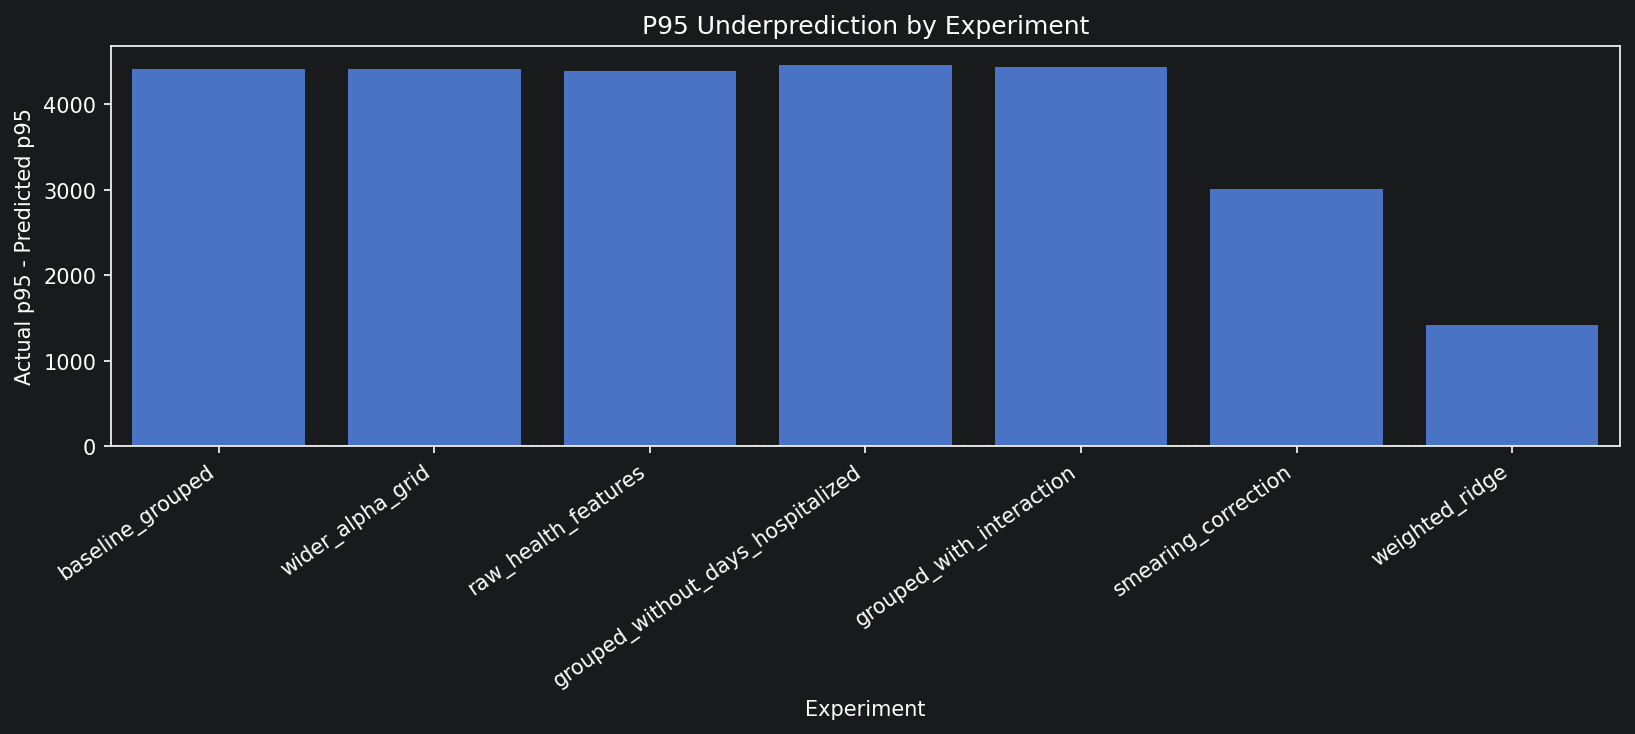

In [10]:
plot_df = comparison_table.copy()

plt.figure(figsize=(11, 5), dpi=150)
sns.barplot(
    data=plot_df,
    x="experiment name",
    y="p95 underprediction",
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("P95 Underprediction by Experiment")
plt.xlabel("Experiment")
plt.ylabel("Actual p95 - Predicted p95")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

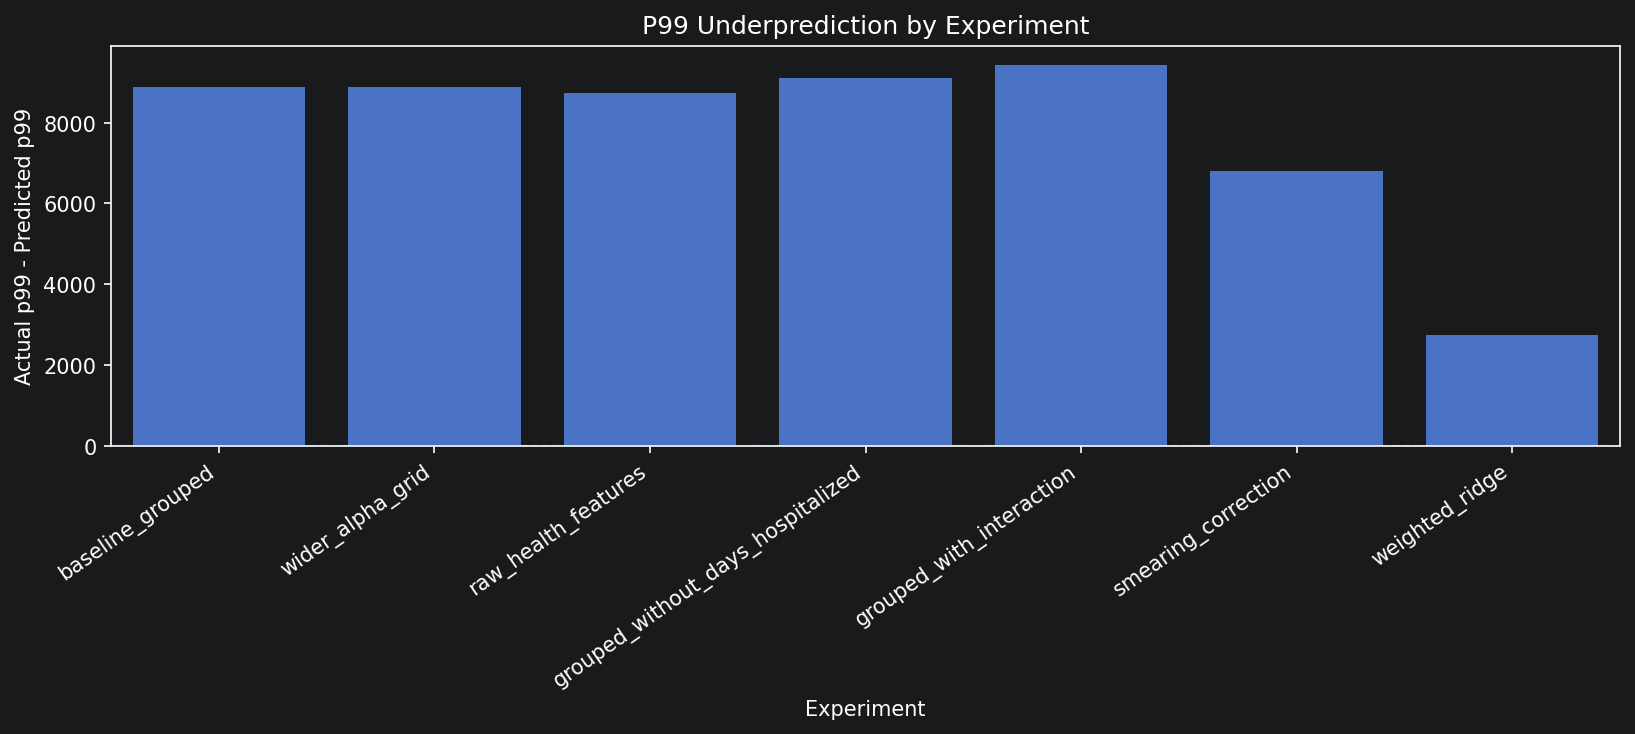

In [11]:
plt.figure(figsize=(11, 5), dpi=150)
sns.barplot(
    data=plot_df,
    x="experiment name",
    y="p99 underprediction",
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("P99 Underprediction by Experiment")
plt.xlabel("Experiment")
plt.ylabel("Actual p99 - Predicted p99")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [12]:
selected_experiment = "baseline_grouped"

display(experiment_predictions[selected_experiment].head())
display(pd.Series(experiment_features[selected_experiment], name="features_used"))

,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,...,had_major_procedure,hospitalizations_grouped,chronic_count_grouped,days_hospitalized_grouped,actual_cost,predicted_cost,residual,absolute_error,actual_log_cost,predicted_log_cost
75721,60,Male,East,Urban,30600.0,Masters,Single,Employed,4,3,...,1,1,1,4+,1640.86,4807.270425,-3166.410425,3166.410425,7.403585,8.478093
80184,40,Male,North,Rural,55900.0,Some College,Married,Employed,2,0,...,0,0,0,0,2306.61,1556.847634,749.762366,749.762366,7.743968,7.351060
19864,55,Male,East,Urban,226200.0,HS,Married,Employed,3,1,...,0,0,0,0,1015.03,2411.209718,-1396.179718,1396.179718,6.923658,7.788299
76699,40,Female,Central,Suburban,70700.0,Some College,Married,Employed,3,1,...,0,0,1,0,1136.82,2067.485403,-930.665403,930.665403,7.036869,7.634572
92991,70,Male,West,Urban,107200.0,No HS,Single,Employed,2,1,...,0,0,2,0,3990.84,3235.766336,755.073664,755.073664,8.292008,8.082330


0                           age
1                           sex
2                        region
3                   urban_rural
4                        income
5                     education
6                marital_status
7             employment_status
8                household_size
9                    dependents
10                          bmi
11                       smoker
12                 alcohol_freq
13             visits_last_year
14             medication_count
15                  systolic_bp
16                 diastolic_bp
17                          ldl
18                        hba1c
19                    plan_type
20                 network_tier
21                   deductible
22                        copay
23            policy_term_years
24     policy_changes_last_2yrs
25             provider_quality
26                   risk_score
27                 hypertension
28                     diabetes
29                       asthma
30                         copd
31      